In [1]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [1]:
import requests
import os
import time
import shutil
from PIL import Image
import random
import tensorflow as tf

API_KEY = "56176072-1983ee0cdada61ad276cb2567" 

In [2]:
subspecies = {
    "domestic_dog": "dog",
    "dingo": "dingo",
    "arctic_wolf": "arctic wolf"
}

download_limit = 500   # images per subspecies
raw_dir = "canis_raw"
os.makedirs(raw_dir, exist_ok=True)

for sub_name, search_term in subspecies.items():
    print(f"\n--- Downloading: {sub_name} (query: '{search_term}') ---")
    target_folder = os.path.join(raw_dir, sub_name)
    os.makedirs(target_folder, exist_ok=True)
    
    downloaded = 0
    page = 1
    per_page = 200   # max per request
    
    while downloaded < download_limit:
        url = f"https://pixabay.com/api/?key={API_KEY}&q={search_term.replace(' ', '+')}&image_type=photo&per_page={per_page}&page={page}&safesearch=true"
        response = requests.get(url)
        data = response.json()
        hits = data.get('hits', [])
        if not hits:
            break
        for hit in hits:
            if downloaded >= download_limit:
                break
            img_url = hit['webformatURL']
            img_data = requests.get(img_url).content
            file_path = os.path.join(target_folder, f"{sub_name}_{downloaded:04d}.jpg")
            with open(file_path, 'wb') as f:
                f.write(img_data)
            downloaded += 1
            print(f"  Downloaded {downloaded}/{download_limit}", end="\r")
        page += 1
        time.sleep(1)   # be polite to the API
    print(f"\nFinished {sub_name}: {downloaded} images")


--- Downloading: domestic_dog (query: 'dog') ---
  Downloaded 500/500
Finished domestic_dog: 500 images

--- Downloading: dingo (query: 'dingo') ---
  Downloaded 32/500
Finished dingo: 32 images

--- Downloading: arctic_wolf (query: 'arctic wolf') ---
  Downloaded 500/500
Finished arctic_wolf: 500 images


In [3]:
def clean_corrupted(root_folder):
    for subdir, _, files in os.walk(root_folder):
        for file in files:
            if file.lower().endswith(('.jpg','.jpeg','.png')):
                path = os.path.join(subdir, file)
                try:
                    with Image.open(path) as img:
                        img.verify()
                except Exception:
                    os.remove(path)
                    print(f"Removed corrupted: {path}")

clean_corrupted(raw_dir)
print("Corrupted images removed.")

Corrupted images removed.


In [4]:
clean_dir = "canis_standardized"
target_size = (224, 224)
os.makedirs(clean_dir, exist_ok=True)

for sub_name in os.listdir(raw_dir):
    src_path = os.path.join(raw_dir, sub_name)
    if not os.path.isdir(src_path):
        continue
    dst_path = os.path.join(clean_dir, sub_name)
    os.makedirs(dst_path, exist_ok=True)
    print(f"Processing {sub_name}...")
    for img_file in os.listdir(src_path):
        img_path = os.path.join(src_path, img_file)
        try:
            with Image.open(img_path) as img:
                img.verify()
            with Image.open(img_path) as img:
                img = img.convert("RGB")
                img = img.resize(target_size)
                out_name = os.path.splitext(img_file)[0] + ".jpg"
                img.save(os.path.join(dst_path, out_name), "JPEG", quality=90)
        except Exception:
            continue
print("Standardization complete.")

Processing arctic_wolf...
Processing dingo...
Processing domestic_dog...
Standardization complete.


In [5]:
raw_dir = "canis_standardized"
output_dir = "final_canis_dataset"

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(output_dir, split), exist_ok=True)

classes = [d for d in os.listdir(raw_dir) if os.path.isdir(os.path.join(raw_dir, d))]

train_ratio, val_ratio = 0.7, 0.15

for cls in classes:
    class_path = os.path.join(raw_dir, cls)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(images)
    train_end = int(len(images) * train_ratio)
    val_end = int(len(images) * (train_ratio + val_ratio))
    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]
    for split_name, img_list in zip(['train','val','test'], [train_imgs, val_imgs, test_imgs]):
        target_dir = os.path.join(output_dir, split_name, cls)
        os.makedirs(target_dir, exist_ok=True)
        for img in img_list:
            shutil.copy2(os.path.join(class_path, img), os.path.join(target_dir, img))
    print(f"{cls}: train={len(train_imgs)}, val={len(val_imgs)}, test={len(test_imgs)}")

print(f"Split complete at '{output_dir}'")

arctic_wolf: train=350, val=75, test=75
dingo: train=22, val=5, test=5
domestic_dog: train=350, val=75, test=75
Split complete at 'final_canis_dataset'


In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(output_dir, 'train'),
    image_size=(224,224),
    batch_size=32,
    label_mode='categorical'
)

print("TensorFlow loaded the dataset.")
print("Class names:", train_ds.class_names)

Found 722 files belonging to 3 classes.
TensorFlow loaded the dataset.
Class names: ['arctic_wolf', 'dingo', 'domestic_dog']


In [8]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.2 MB 15.1 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.2 MB 13.9 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 12.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 16.8 MB/s  0:00:00

   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
  

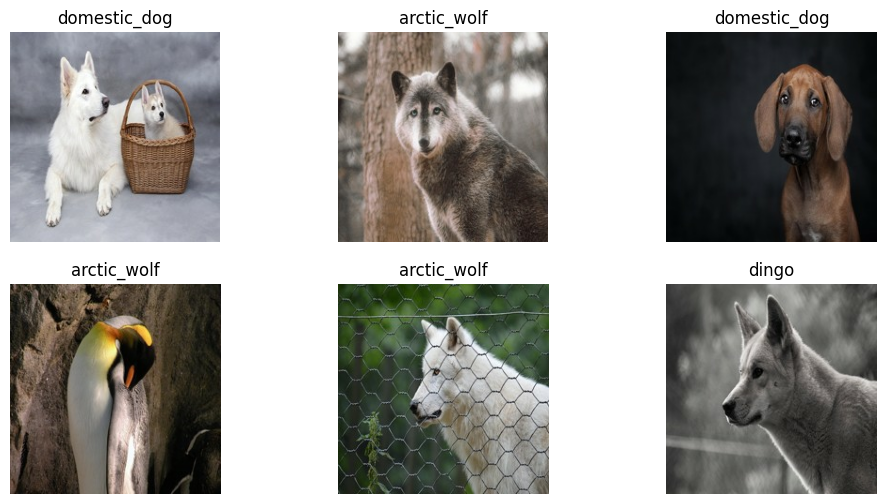

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(6):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        class_idx = tf.argmax(labels[i]).numpy()
        plt.title(train_ds.class_names[class_idx])
        plt.axis('off')
    plt.show()

In [10]:
import zipfile

with zipfile.ZipFile('final_canis_dataset.zip', 'w') as zipf:
    for root, dirs, files in os.walk('final_canis_dataset'):
        for file in files:
            zipf.write(os.path.join(root, file))
print("Dataset zipped as 'final_canis_dataset.zip'")

Dataset zipped as 'final_canis_dataset.zip'


In [11]:
import os
os.startfile("final_canis_dataset")

In [12]:
import tensorflow as tf

# Path to your final dataset folder
data_dir = "final_canis_dataset"

# Load training set
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f'{data_dir}/train',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# Load validation set
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f'{data_dir}/val',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# Load test set
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f'{data_dir}/test',
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

print("✅ TensorFlow successfully loaded the cleaned dataset.")
print("Class names:", train_ds.class_names)

# Optional: show a batch shape
for images, labels in train_ds.take(1):
    print(f"Batch images shape: {images.shape}")
    print(f"Batch labels shape: {labels.shape}")
    break

Found 722 files belonging to 3 classes.
Found 155 files belonging to 3 classes.
Found 155 files belonging to 3 classes.
✅ TensorFlow successfully loaded the cleaned dataset.
Class names: ['arctic_wolf', 'dingo', 'domestic_dog']
Batch images shape: (32, 224, 224, 3)
Batch labels shape: (32, 3)


In [13]:
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, DenseNet121, MobileNetV3Large
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobile_preprocess
import matplotlib.pyplot as plt

# 1. Define configuration constants
DATA_DIR = "final_canis_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3

# 2. Load the datasets using categorical labels (one-hot encoded)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'val'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False # Keep evaluation datasets consistent
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

# Prefetch for performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Classes identified:", train_ds.class_names)

Found 722 files belonging to 3 classes.
Found 155 files belonging to 3 classes.
Found 155 files belonging to 3 classes.


AttributeError: '_PrefetchDataset' object has no attribute 'class_names'